### Task 4  (`mpg.csv`)

**Name:** Ali Afzal
**Roll No.:** SU92-BSAIM-F23-102
**Subject:** Data Visualization

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA = Path("data")

# House style copied from the Week 1 lecture: colour-blind-safe palette,
# left-aligned titles, no chart box, light grid.
BLUE, ORANGE, AQUA, YELLOW = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
MAGENTA, GREEN, VIOLET, RED = "#e87ba4", "#008300", "#4a3aa7", "#e34948"
INK, INK_SOFT, INK_MUTED = "#0b0b0b", "#52514e", "#8a8985"
GRID, SURFACE, QUIET = "#e6e5e1", "#fcfcfb", "#cfceca"

plt.rcParams.update({
    "figure.figsize": (8, 4.5), "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": INK_SOFT, "axes.titlecolor": INK,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.titlepad": 14, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "xtick.color": INK_SOFT, "ytick.color": INK_SOFT, "legend.frameon": False,
    "lines.linewidth": 2, "font.size": 11,
})


def note(ax, text, y=-0.2):
    # Grey footnote under a chart - used to say which rows were left out.
    ax.text(0, y, text, transform=ax.transAxes, fontsize=9, color=INK_MUTED)

In [2]:
df = pd.read_csv(DATA / "mpg.csv")
df["origin"] = df["origin"].map({"usa": "American", "europe": "European", "japan": "Japanese"})
df["year"] = 1900 + df["model_year"]
print(df.shape)
df.isna().sum()

(398, 10)


mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
year            0
dtype: int64

Only `horsepower` has gaps (6 cars). None of my five questions use horsepower, so I **keep all 398 cars** in
every chart. Dropping those 6 would have thrown away good mpg and weight data for no reason.

### Q1. Did cars get more fuel-efficient between 1970 and 1982?

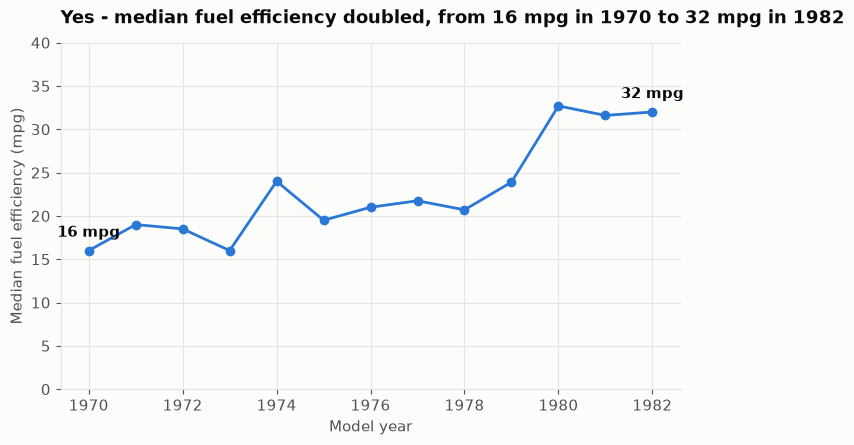

In [3]:
yearly = df.groupby("year")["mpg"].median()

fig, ax = plt.subplots()
ax.plot(yearly.index, yearly.values, color=BLUE, marker="o")
for year in (1970, 1982):
    ax.annotate(f"{yearly[year]:.0f} mpg", (year, yearly[year]), xytext=(0, 10),
                textcoords="offset points", ha="center", fontweight="bold", color=INK)

ax.set_ylim(0, 40)
ax.set_title("Yes - median fuel efficiency doubled, from 16 mpg in 1970 to 32 mpg in 1982")
ax.set_xlabel("Model year")
ax.set_ylabel("Median fuel efficiency (mpg)")
plt.show()

**Why:** model year is an ordered scale and the question is about change over time, so a line chart. I used the
median instead of the mean so a few very economical cars can't pull the line up.

### Q2. Do American, European and Japanese cars differ in fuel efficiency?

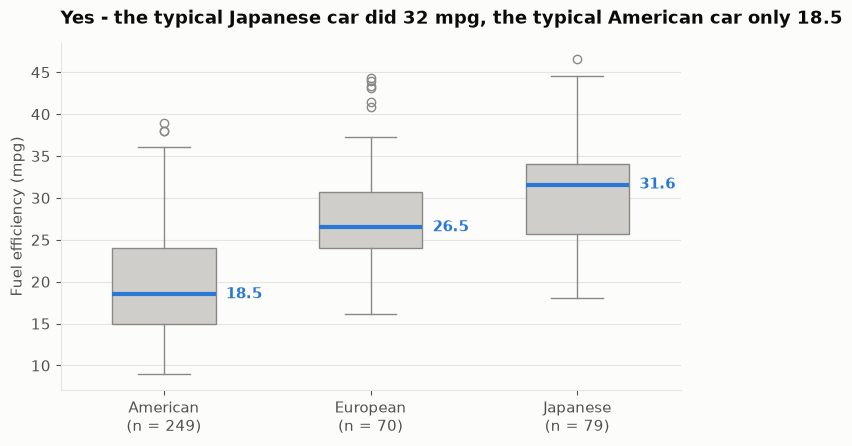

In [4]:
order = df.groupby("origin")["mpg"].median().sort_values().index
groups = [df.loc[df["origin"] == o, "mpg"] for o in order]
labels = [f"{o}\n(n = {len(g)})" for o, g in zip(order, groups)]

fig, ax = plt.subplots()
ax.boxplot(groups, tick_labels=labels, widths=0.5, patch_artist=True,
           boxprops={"facecolor": QUIET, "edgecolor": INK_MUTED},
           medianprops={"color": BLUE, "linewidth": 3},
           whiskerprops={"color": INK_MUTED}, capprops={"color": INK_MUTED},
           flierprops={"markeredgecolor": INK_MUTED})
for k, g in enumerate(groups, start=1):
    ax.text(k + 0.3, g.median(), f"{g.median():.1f}", va="center", color=BLUE, fontweight="bold")

ax.set_title("Yes - the typical Japanese car did 32 mpg, the typical American car only 18.5")
ax.set_ylabel("Fuel efficiency (mpg)")
ax.xaxis.grid(False)
plt.show()

**Why:** I'm comparing a whole distribution across three groups, so a box plot, which shows the median, the
spread and how much the groups overlap. A bar of averages would hide the fact that American cars range from
about 9 to 39 mpg. I sorted the groups by median, since origin has no natural order.

(Origin is probably not the whole story though. American cars were also bigger and heavier, which is Q3.)

#### Q3. What is the relationship between a car's weight and its fuel efficiency?

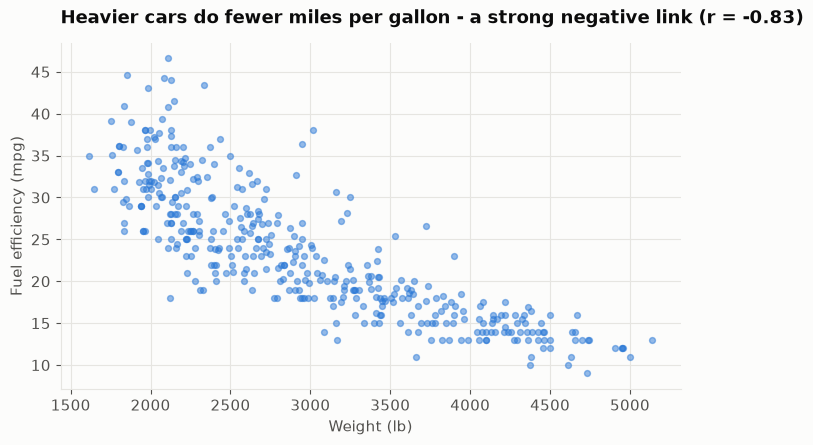

In [5]:
r = df["weight"].corr(df["mpg"])

fig, ax = plt.subplots()
ax.scatter(df["weight"], df["mpg"], s=18, color=BLUE, alpha=0.5)
ax.set_title(f"Heavier cars do fewer miles per gallon - a strong negative link (r = {r:.2f})")
ax.set_xlabel("Weight (lb)")
ax.set_ylabel("Fuel efficiency (mpg)")
plt.show()

**Why:** two numeric variables and a question about whether they move together, so a scatter plot. It shows
the relationship itself: it is strong, it is negative, and it bends slightly (the drop in mpg flattens out for
the heaviest cars), which one correlation number would not tell you.

### Q4. How is the number of cylinders distributed across the fleet?

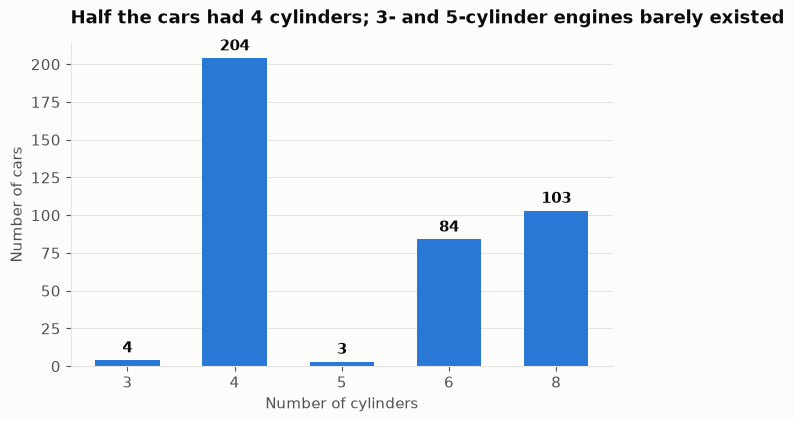

In [6]:
cyl = df["cylinders"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 4.2))
bars = ax.bar(cyl.index.astype(str), cyl.values, color=BLUE, width=0.6)
ax.bar_label(bars, padding=3, fontweight="bold", color=INK)
ax.set_title("Half the cars had 4 cylinders; 3- and 5-cylinder engines barely existed")
ax.set_xlabel("Number of cylinders")
ax.set_ylabel("Number of cars")
ax.xaxis.grid(False)
plt.show()

**Why:** I'm counting cars in five separate categories, so a bar chart starting at zero, with the counts written on
the bars. Cylinders only come in whole numbers, so it isn't a histogram, and a pie with five slices (two of them
tiny) would break the four-slice rule. I kept the categories in numeric order instead of sorting by size,
because cylinder count is naturally ordered.

### Q5. Is the improvement in Q1 explained by Q3? (Did cars get lighter?)

To answer this I have to separate the two effects: compare early and late cars **of the same weight**. If
weight explained everything, a 1980 car and a 1972 car of the same weight would get the same mpg.

In [7]:
df["era"] = pd.cut(df["year"], [1969, 1974, 1977, 1982], labels=["1970-74", "1975-77", "1978-82"])
df["band"] = pd.cut(df["weight"], [0, 2300, 2800, 3300, 3800, 6000],
                    labels=["Under 2,300", "2,300-2,800", "2,800-3,300", "3,300-3,800", "Over 3,800"])

print("Median weight by era (lb):")
print(df.groupby("era", observed=True)["weight"].median())

compare = (df[df["era"] != "1975-77"]
           .groupby(["band", "era"], observed=True)["mpg"].median()
           .unstack())
compare

Median weight by era (lb):
era
1970-74    3053.5
1975-77    3062.0
1978-82    2617.5
Name: weight, dtype: float64


era,1970-74,1978-82
band,,
"Under 2,300",26.5,35.10
"2,300-2,800",22.0,28.00
"2,800-3,300",18.5,23.70
"3,300-3,800",16.0,19.30
"Over 3,800",13.0,17.25


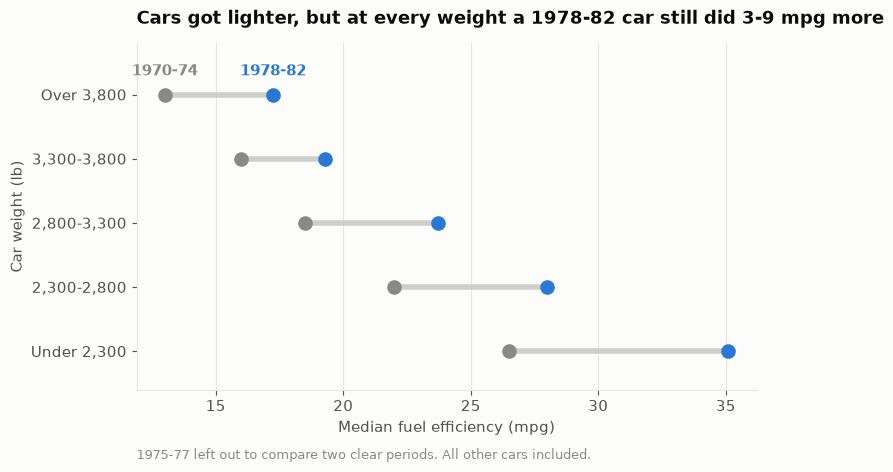

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.5))
y = np.arange(len(compare))
ax.hlines(y, compare["1970-74"], compare["1978-82"], color=QUIET, linewidth=4)
ax.scatter(compare["1970-74"], y, s=90, color=INK_MUTED, zorder=3)
ax.scatter(compare["1978-82"], y, s=90, color=BLUE, zorder=3)
ax.text(compare["1970-74"].iloc[-1], y[-1] + 0.3, "1970-74", ha="center", color=INK_MUTED, fontweight="bold")
ax.text(compare["1978-82"].iloc[-1], y[-1] + 0.3, "1978-82", ha="center", color=BLUE, fontweight="bold")

ax.set_yticks(y, compare.index)
ax.set_ylim(-0.6, len(compare) - 0.2)
ax.set_title("Cars got lighter, but at every weight a 1978-82 car still did 3-9 mpg more")
ax.set_xlabel("Median fuel efficiency (mpg)")
ax.set_ylabel("Car weight (lb)")
ax.yaxis.grid(False)
note(ax, "1975-77 left out to compare two clear periods. All other cars included.", y=-0.2)
plt.show()

**Why:** this is a dot plot (dumbbell chart). Each row is a weight band, the grey dot is early cars and the blue
dot is late cars. Holding weight fixed like this is exactly what the question needs, and a scatter plot of all
398 cars would make this hard to see. The x-axis doesn't start at zero, but that is fine for dots, because what
you read is their position, not the length of a bar.

**Answer: only partly.** Cars did get lighter. The median weight fell from about 3,050 lb in 1970-74 to about
2,620 lb in 1978-82, and the number of cars over 3,800 lb fell from 49 to 8. But in every weight band the later
cars still do better, by about 3 to 9 mpg. So lighter cars explain part of the improvement, and the rest came from
something else, probably better engines and technology after the 1973 and 1979 oil crises and the new US
fuel-economy rules.

### Redrawing my weakest chart

My weakest chart is **Q1**. It shows one median per year and nothing else, so it hides two things:

- **How spread out each year is.** A median of 16 mpg in 1970 could mean every car is near 16, or it could mean
  cars ranging from 9 to 27. The reader can't tell.
- **How much to trust the wiggles.** There are only about 30 cars per year, so the jumps (like 16 in 1973 to 24
  in 1974) might just be which models happened to be in the sample.

I changed it by putting **every car behind the line as a faint grey dot** (with a little sideways jitter so the dots
don't hide each other), and kept the median line in blue on top. Grey for the context, colour for the message.
I also changed the title, because now the chart shows something new that the old one could not.

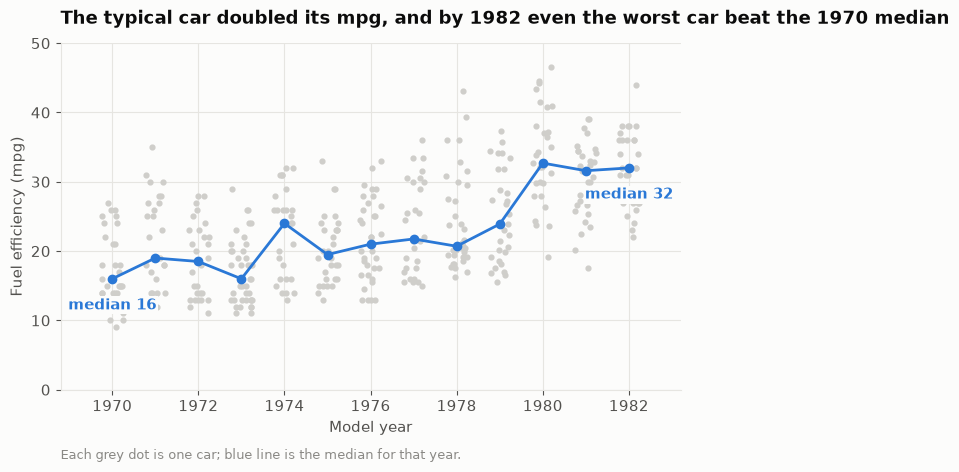

In [9]:
jitter = np.random.default_rng(0).uniform(-0.25, 0.25, len(df))

fig, ax = plt.subplots()
ax.scatter(df["year"] + jitter, df["mpg"], s=12, color=QUIET)
ax.plot(yearly.index, yearly.values, color=BLUE, marker="o", zorder=3)
for year in (1970, 1982):
    ax.annotate(f"median {yearly[year]:.0f}", (year, yearly[year]), xytext=(0, -22),
                textcoords="offset points", ha="center", fontweight="bold", color=BLUE,
                bbox={"facecolor": SURFACE, "edgecolor": "none", "pad": 1})

ax.set_xlim(1968.8, 1983.2)
ax.set_ylim(0, 50)
ax.set_title("The typical car doubled its mpg, and by 1982 even the worst car beat the 1970 median")
ax.set_xlabel("Model year")
ax.set_ylabel("Fuel efficiency (mpg)")
note(ax, "Each grey dot is one car; blue line is the median for that year.", y=-0.2)
plt.show()

Now the whole picture is on one chart: the typical car doubled its mpg, and the whole cloud moved up, not just
the middle. In 1970 cars ranged from 9 to 27 mpg. In 1982 the *worst* car did 22 mpg, which is better than the
1970 median of 16. You can also see that each year's spread is wide, so the small year-to-year zigzags in the
median should not be over-read.